<a href="https://colab.research.google.com/github/KushanavoRakshit/Titanic_KC/blob/main/titanic4_kcSP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
kagglehub.login()
titanic_path = kagglehub.competition_download('titanic')
print('Data source import complete.')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [ ]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

print(train.shape)
train.head()



(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
train.info()
train.describe()
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

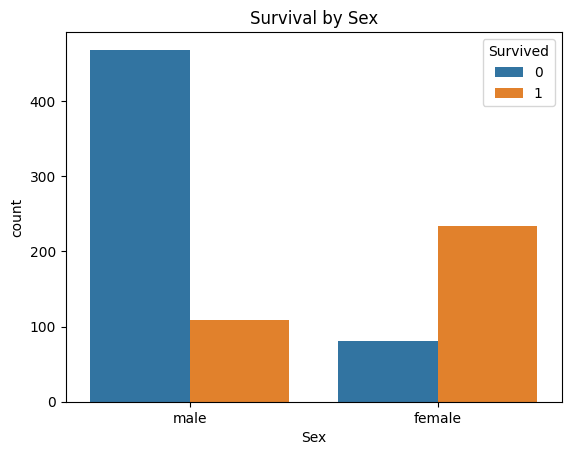

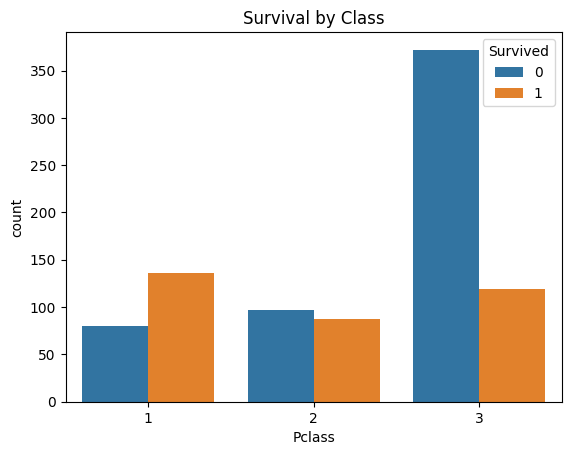

In [ ]:
sns.countplot(data=train, x='Sex', hue='Survived')
plt.title('Survival by Sex')
plt.show()
sns.countplot(data=train, x='Pclass', hue='Survived')
plt.title('Survival by Class')
plt.show()


In [ ]:
# Imputation
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(train['Age'].median(), inplace=True)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)
test['Fare'].fillna(test['Fare'].median(), inplace=True)

# Encoding
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})
train['Embarked'] = train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test['Embarked'] = test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})



/tmp/ipykernel_55/2999684559.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
/tmp/ipykernel_55/2999684559.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [ ]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X_train = train[features]
y_train = train['Survived']
X_test = test[features]

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
# Step 1: Baseline linear kernel
linear_model = SVC(kernel='linear', random_state=42)
linear_model.fit(X_train_scaled, y_train)
linear_preds = linear_model.predict(X_train_scaled)
print('Linear Kernel Training Accuracy:', accuracy_score(y_train, linear_preds))


Linear Kernel Training Accuracy: 0.7867564534231201


In [ ]:
# Step 2: RBF with C=1, 5, 10
for C_val in [1, 5, 10]:
    rbf_model = SVC(kernel='rbf', C=C_val, gamma='scale', random_state=42)
    rbf_model.fit(X_train_scaled, y_train)
    preds = rbf_model.predict(X_train_scaled)
    print(f'RBF Kernel (C={C_val}) Training Accuracy: {accuracy_score(y_train, preds):.4f}')



RBF Kernel (C=1) Training Accuracy: 0.8451
RBF Kernel (C=5) Training Accuracy: 0.8496
RBF Kernel (C=10) Training Accuracy: 0.8575


In [ ]:
# Step 3: GridSearchCV over C, gamma, and kernel
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C':      [0.1, 1, 5, 10, 50],
    'gamma':  ['scale', 'auto', 0.01, 0.001]
}

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print('\nBest Parameters :', grid_search.best_params_)
print('Best CV Accuracy :', round(grid_search.best_score_, 4))


Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy : 0.8316


In [ ]:
# Step 4: Final model with best params
best_model = grid_search.best_estimator_

train_preds = best_model.predict(X_train_scaled)
print('Final Training Accuracy:', round(accuracy_score(y_train, train_preds), 4))


Final Training Accuracy: 0.8451


In [ ]:
# Step 5: Submission
predictions = best_model.predict(X_test_scaled)
submission = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': predictions})
submission.to_csv('/kaggle/working/submission.csv', index=False)
print('\nDone! File saved.')
submission.head(10)



Done! File saved.


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0
